In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("financial_news_cleaned.csv")

In [3]:
df.head()

,Date,Headline,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Year,Month
0,21-05-2025,Nikkei 225 index benefits from a weaker yen,Times of India,Commodity Price Shock,DAX,3.52,166.45,NaN,Technology,High,2025,May
1,18-05-2025,Government subsidy program gives a lift to the...,Financial Times,Central Bank Meeting,Shanghai Composite,-3.39,57.61,NaN,Retail,Low,2025,May
2,25-06-2025,New housing data release shows a slowdown in m...,The Hindu Business Line,Consumer Confidence Report,Shanghai Composite,-0.05,403.22,Neutral,Retail,Medium,2025,June
3,21-07-2025,Massive stock buyback program announced by a c...,The Economist,Commodity Price Shock,NSE Nifty,-2.29,100.11,Positive,Consumer Goods,Low,2025,July
4,23-07-2025,Government spending bill is expected to stimul...,The Motley Fool,Inflation Data Release,Nasdaq Composite,-3.97,438.22,Negative,Consumer Goods,Low,2025,July


In [4]:
## How many records are present in the dataset?

df.shape

(2863, 12)

In [5]:
df.columns

Index(['Date', 'Headline', 'Source', 'Market_Event', 'Market_Index',
       'Index_Change_Percent', 'Trading_Volume', 'Sentiment', 'Sector',
       'Impact_Level', 'Year', 'Month'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2863 entries, 0 to 2862
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  2863 non-null   object 
 1   Headline              2720 non-null   object 
 2   Source                2863 non-null   object 
 3   Market_Event          2863 non-null   object 
 4   Market_Index          2863 non-null   object 
 5   Index_Change_Percent  2863 non-null   float64
 6   Trading_Volume        2863 non-null   float64
 7   Sentiment             2704 non-null   object 
 8   Sector                2863 non-null   object 
 9   Impact_Level          2863 non-null   object 
 10  Year                  2863 non-null   int64  
 11  Month                 2863 non-null   object 
dtypes: float64(2), int64(1), object(9)
memory usage: 268.5+ KB


In [8]:
df.describe()

,Index_Change_Percent,Trading_Volume,Year
count,2863.000000,2863.000000,2863.0
mean,-0.021753,249.784876,2025.0
std,2.851991,145.414649,0.0
min,-4.990000,1.060000,2025.0
25%,-2.450000,122.005000,2025.0
50%,-0.100000,244.280000,2025.0
75%,2.475000,377.955000,2025.0
max,5.000000,499.830000,2025.0


In [23]:
## How many news events are available for each sentiment?

df['sentiment'].value_counts()

sentiment
Negative    931
Neutral     889
Positive    884
Name: count, dtype: int64

In [24]:
## Which sector has the highest number of news events?

df['sector'].value_counts()

sector
Transportation           172
Technology               171
Agriculture              169
Materials                167
Automotive               165
Industrials              164
Utilities                163
Energy                   162
Media & Entertainment    160
Telecommunications       157
Real Estate              157
Retail                   154
Aerospace & Defense      153
Construction             153
Healthcare               152
Consumer Goods           151
Finance                  147
Pharmaceuticals          146
Name: count, dtype: int64

In [7]:
## Are there any missing values in the dataset?

df.isnull().sum()

Date                      0
Headline                143
Source                    0
Market_Event              0
Market_Index              0
Index_Change_Percent      0
Trading_Volume            0
Sentiment               159
Sector                    0
Impact_Level              0
Year                      0
Month                     0
dtype: int64

In [25]:
## What is the average market change by sentiment

df.groupby('sentiment')['index_change_percent'].mean()

sentiment
Negative   -0.035822
Neutral     0.096839
Positive   -0.106007
Name: index_change_percent, dtype: float64

In [26]:
## Find top 5 highest trading volume events.

df.sort_values(
'trading_volume',
ascending=False
).head(5)

,date,headline,source,market_event,market_index,index_change_percent,trading_volume,sentiment,sector,impact_level,year,month
895,2025-05-12,Pharmaceutical company's drug approval drives ...,The Motley Fool,Bond Market Fluctuation,Russell 2000,-1.61,499.83,Positive,Agriculture,Low,2025,May
2343,2025-07-04,Semiconductor shortages weigh heavily on tech ...,Barron's,Inflation Data Release,Dow Jones,-2.71,499.60,Negative,Telecommunications,Medium,2025,July
478,2025-07-29,Massive stock buyback program announced by a c...,Bloomberg,Consumer Confidence Report,S&P/TSX Composite,-0.29,499.29,Negative,Finance,Medium,2025,July
2181,2025-02-05,Market sentiment turns positive on vaccine tri...,The Economist,Unemployment Rate Announcement,IBOVESPA,-4.75,499.28,Positive,Energy,Medium,2025,February
538,2025-05-05,Record-high inflation data rattles investors,The Economist,Central Bank Meeting,NSE Nifty,3.45,499.27,Neutral,Retail,Medium,2025,May


In [27]:
## Find top 5 highest market movement news.

df.sort_values(
'index_change_percent',
ascending=False
).head(5)

,date,headline,source,market_event,market_index,index_change_percent,trading_volume,sentiment,sector,impact_level,year,month
1661,2025-04-11,NaN,Yahoo Finance,Corporate Earnings Report,Shanghai Composite,5.00,281.82,Negative,Healthcare,Low,2025,April
819,2025-06-29,New housing data release shows a slowdown in m...,MarketWatch,Commodity Price Shock,NSE Nifty,5.00,487.76,Negative,Healthcare,Medium,2025,June
601,2025-02-09,NaN,CNBC,Trade Tariffs Announcement,IBOVESPA,4.99,112.07,Positive,Energy,Low,2025,February
57,2025-04-14,Banking stocks dip after a major scandal is re...,Financial Times,Cryptocurrency Regulation,Hang Seng,4.99,314.53,Negative,Agriculture,Low,2025,April
2494,2025-02-24,Consumer Discretionary stocks outperform as sp...,The Motley Fool,Supply Chain Disruption,Russell 2000,4.99,176.58,Positive,Utilities,High,2025,February


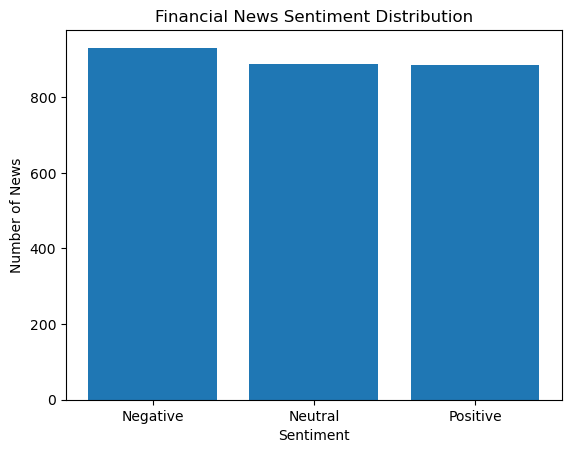

In [22]:
## What is the distribution of financial news sentiment?

import matplotlib.pyplot as plt

sentiment_count = df['sentiment'].value_counts()
plt.bar(sentiment_count.index, sentiment_count.values)
plt.title("Financial News Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of News")

plt.show()

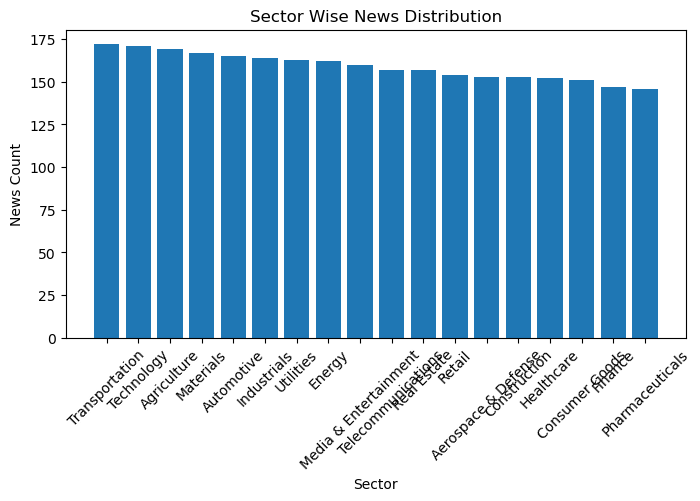

In [23]:
## Which sector has more financial news coverage?

sector_count = df['sector'].value_counts()
plt.figure(figsize=(8,4))
plt.bar(sector_count.index, sector_count.values)
plt.xticks(rotation=45)
plt.title("Sector Wise News Distribution")
plt.xlabel("Sector")
plt.ylabel("News Count")

plt.show()

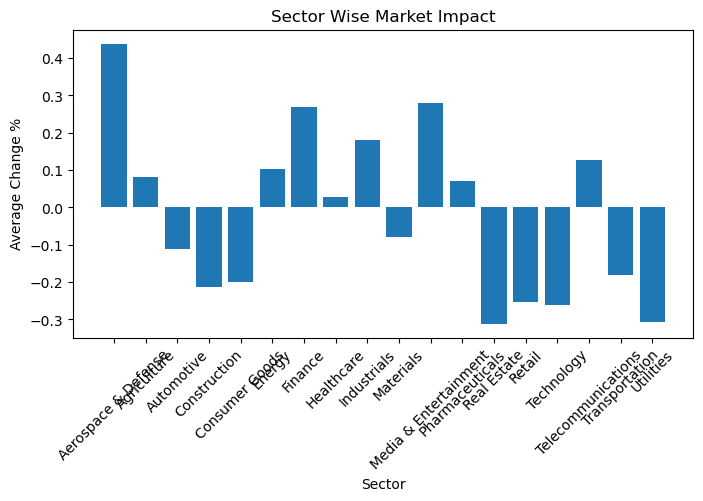

In [24]:
## Which sector shows higher market movement?

sector_change = df.groupby('sector')['index_change_percent'].mean()
plt.figure(figsize=(8,4))
plt.bar(
sector_change.index,
sector_change.values
)

plt.xticks(rotation=45)
plt.title("Sector Wise Market Impact")
plt.xlabel("Sector")
plt.ylabel("Average Change %")

plt.show()

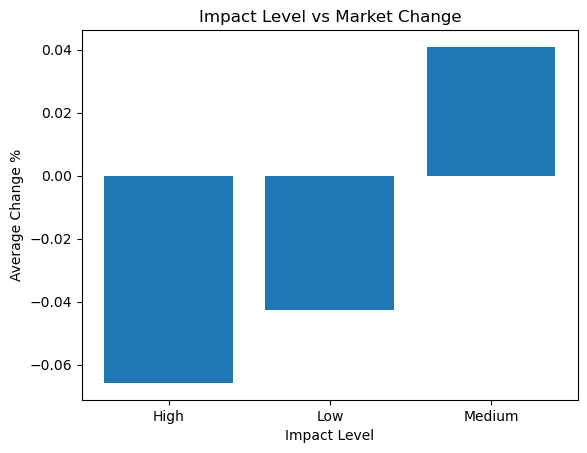

In [25]:
##  Impact Level Analysis

impact = df.groupby('impact_level')['index_change_percent'].mean()
plt.bar(
impact.index,
impact.values
)
plt.title("Impact Level vs Market Change")
plt.xlabel("Impact Level")
plt.ylabel("Average Change %")

plt.show()

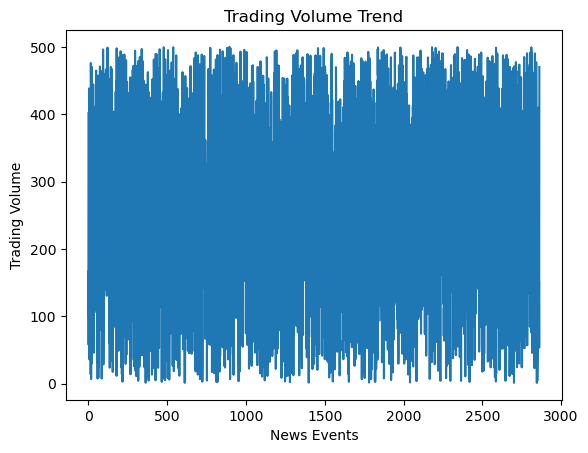

In [26]:
## Trading Volume Trend

plt.plot(df['trading_volume'])
plt.title("Trading Volume Trend")
plt.xlabel("News Events")
plt.ylabel("Trading Volume")

plt.show()

In [27]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
## What is the average market change percentage?

import numpy as np

average_change = np.mean(df['index_change_percent'])
average_change

In [28]:
## What is the maximum market movement recorded?

maximum_change = np.max(df['index_change_percent'])
maximum_change

5.0

In [29]:
##  What is the minimum market movement recorded?

minimum_change = np.min(df['index_change_percent'])
minimum_change

-4.99

In [30]:
## What is the total trading volume?

total_volume = np.sum(df['trading_volume'])
total_volume

np.float64(715134.1)

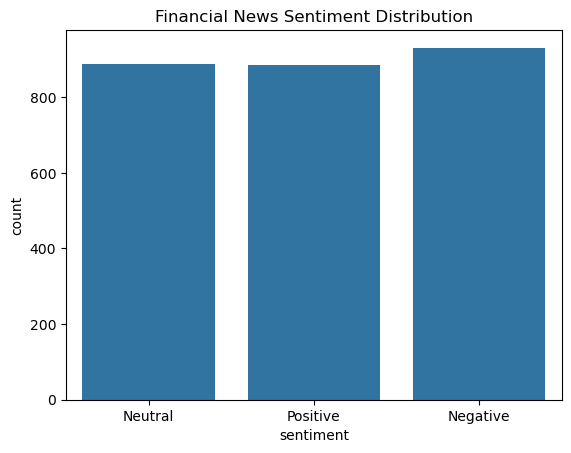

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(
    x='sentiment',
    data=df
)
plt.title("Financial News Sentiment Distribution")

plt.show()

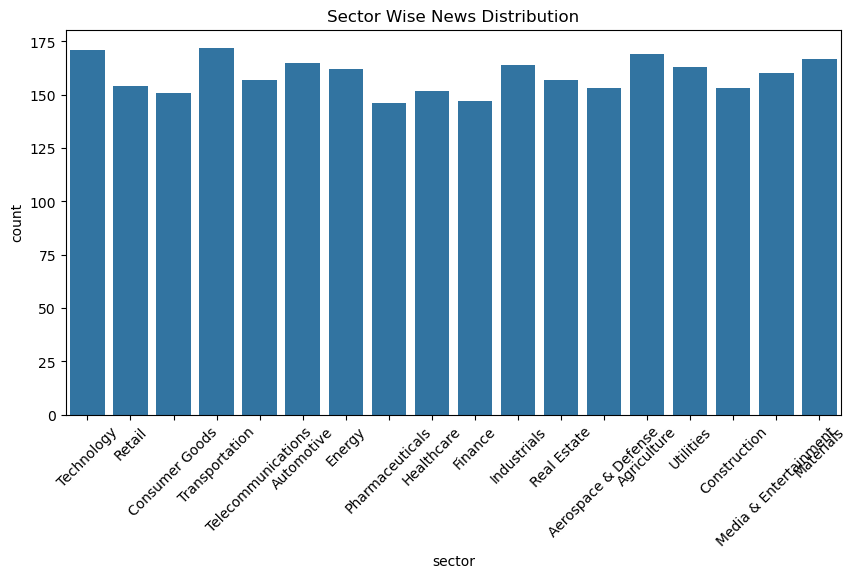

In [32]:
##  Which sector has the highest number of news events?

plt.figure(figsize=(10,5))
sns.countplot(
    x='sector',
    data=df
)
plt.xticks(rotation=45)
plt.title("Sector Wise News Distribution")

plt.show()

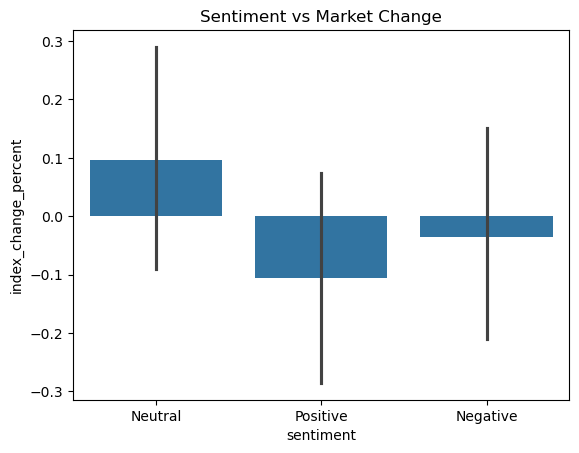

In [33]:
##  How does sentiment affect market change?

sns.barplot(
    x='sentiment',
    y='index_change_percent',
    data=df
)
plt.title("Sentiment vs Market Change")

plt.show()

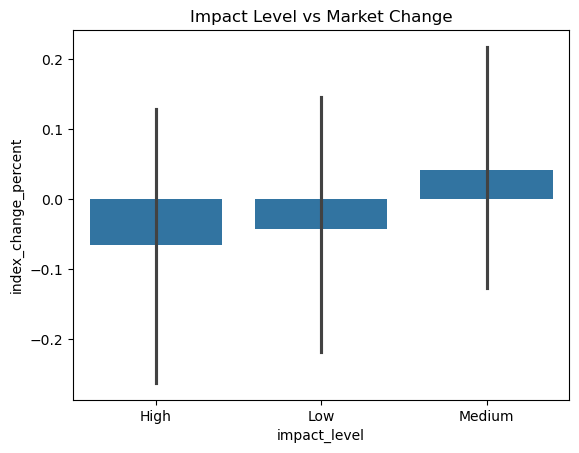

In [34]:
##  Does impact level affect market movement?

sns.barplot(
    x='impact_level',
    y='index_change_percent',
    data=df
)
plt.title("Impact Level vs Market Change")

plt.show()

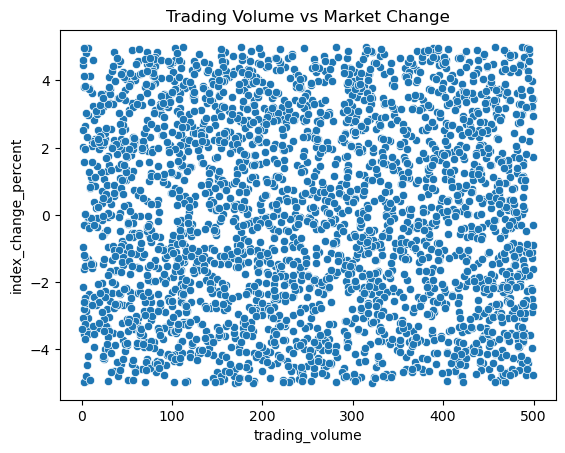

In [35]:
## Relationship between trading volume and market change

sns.scatterplot(
    x='trading_volume',
    y='index_change_percent',
    data=df
)
plt.title("Trading Volume vs Market Change")

plt.show()

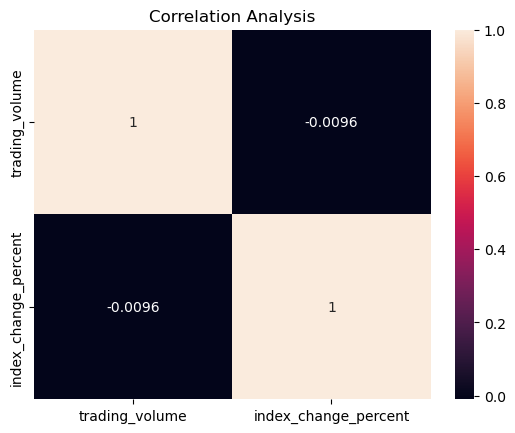

In [36]:
## Correlation Analysis

sns.heatmap(
    df[['trading_volume','index_change_percent']].corr(),
    annot=True
)
plt.title("Correlation Analysis")

plt.show()